# Part 1.2: IBTrACS Storm Selection

This notebook selects a small, defensible set of storm events for downstream DYAMOND window extraction.

## Goals
The immediate goal of this notebook is to rank storms, select roughly 6–10 events, and save an event catalog for later extraction and analysis.
1. Load the storm summary parquet built from cleaned IBTrACS data.
2. Audit the candidate storm pool.
3. Define transparent eligibility filters.
4. Rank storms using simple, interpretable criteria.
5. Select a final set of events for analysis.
6. Save:
   - a ranked candidate table
   - a final event catalog for downstream extraction

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_rows", 200)

# proj root relative to notebook pwd
PROJECT_ROOT = Path.cwd().resolve().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
INTERIM_DIR = DATA_DIR / "interim"
EVENTS_DIR = INTERIM_DIR / "event_catalog"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

INTERIM_DIR.mkdir(parents=True, exist_ok=True)
OUTPUTS_DIR.mkdir(parents=True, exist_ok=True)

# inputs
STORM_SUMMARY_PATH = EVENTS_DIR / "ibtracs_storm_summary.parquet"
POINTS_PATH = EVENTS_DIR / "ibtracs_points.parquet" 

# outputs
RANKED_CANDIDATES_PARQUET = INTERIM_DIR / "storm_candidates_ranked.parquet"
RANKED_CANDIDATES_CSV = INTERIM_DIR / "storm_candidates_ranked.csv"
EVENT_CATALOG_PARQUET = PROCESSED_DIR / "event_catalog.parquet"
EVENT_CATALOG_CSV = PROCESSED_DIR / "event_catalog.csv"

print("PROJECT_ROOT =", PROJECT_ROOT)
print("STORM_SUMMARY_PATH exists:", STORM_SUMMARY_PATH.exists())
print("POINTS_PATH exists:", POINTS_PATH.exists())

PROJECT_ROOT = /home/exouser/SciVis_2026
STORM_SUMMARY_PATH exists: True
POINTS_PATH exists: True


## Load storm summary data

The storm summary table should contain one row per storm (`SID`) and include storm metadata such as temporal extent, basic track geometry, and intensity indicators.

Before making any storm selections, verify:
- file exists
- row count
- column names
- basic data types
- uniqueness of `SID`
- missingness in critical fields

In [2]:
if not STORM_SUMMARY_PATH.exists():
    raise FileNotFoundError(f"Storm summary parquet not found: {STORM_SUMMARY_PATH}")

storms = pd.read_parquet(STORM_SUMMARY_PATH).copy()
print("Storm summary shape:", storms.shape)
print("\nColumns:")
print(sorted(storms.columns.tolist()))
storms.head()

Storm summary shape: (139, 18)

Columns:
['SID', 'basin', 'duration_hours', 'end_time', 'has_pressure', 'has_wind', 'max_lat', 'max_lon_180', 'max_wind_kt', 'min_lat', 'min_lon_180', 'min_pres_mb', 'n_points', 'name', 'nature', 'season', 'start_time', 'track_type']


,SID,start_time,end_time,n_points,season,basin,name,nature,track_type,min_lat,max_lat,min_lon_180,max_lon_180,max_wind_kt,min_pres_mb,duration_hours,has_wind,has_pressure
0,2020015S12170,2020-01-20 00:00:00+00:00,2020-01-20 12:00:00+00:00,5,2020,SP,TINO,NR,main,-40.6,-35.8,-160.3,-156.5,-1.0,<NA>,12.0,True,False
1,2020019S11063,2020-01-20 00:00:00+00:00,2020-01-24 06:00:00+00:00,35,2020,SI,UNNAMED,TS,main,-29.8,-11.5,64.5,73.8,45.0,998.0,102.0,True,True
2,2020022S17043,2020-01-22 06:00:00+00:00,2020-01-29 18:00:00+00:00,61,2020,SI,DIANE,DS,main,-35.5,-16.7,43.2,71.6,55.0,985.0,180.0,True,True
3,2020023S19056,2020-01-22 12:00:00+00:00,2020-01-26 12:00:00+00:00,33,2020,SI,ESAMI,DS,main,-28.6,-18.9,56.0,77.0,45.0,991.0,96.0,True,True
4,2020024S14190,2020-01-24 06:00:00+00:00,2020-01-28 18:00:00+00:00,37,2020,SP,UNNAMED,DS,main,-24.5,-14.3,-169.6,-165.9,35.0,1000.0,108.0,True,True


In [3]:
# verify datetime columns are parsed
for col in ["start_time", "end_time"]:
    if col in storms.columns:
        storms[col] = pd.to_datetime(storms[col], utc=True, errors="coerce")

# schema based on the IBTrACS summary builder
required_cols = ["SID", "start_time", "end_time", "n_points", "duration_hours"]

missing_required = [c for c in required_cols if c not in storms.columns]
if missing_required:
    raise ValueError(f"Missing required storm summary columns: {missing_required}")

print("Unique SID count:", storms["SID"].nunique())
print("Row count:", len(storms))
print("Rows with duplicated SID:", storms["SID"].duplicated().sum())

Unique SID count: 139
Row count: 139
Rows with duplicated SID: 0


In [4]:
validation_summary = pd.DataFrame({
    "column": storms.columns,
    "dtype": [storms[c].dtype for c in storms.columns],
    "missing_count": [storms[c].isna().sum() for c in storms.columns],
    "missing_frac": [storms[c].isna().mean() for c in storms.columns],
}).sort_values(["missing_frac", "column"], ascending=[False, True])

validation_summary

,column,dtype,missing_count,missing_frac
5,basin,object,31,0.223022
14,min_pres_mb,Float64,2,0.014388
0,SID,object,0,0.000000
15,duration_hours,float64,0,0.000000
2,end_time,"datetime64[ns, UTC]",0,0.000000
17,has_pressure,bool,0,0.000000
16,has_wind,bool,0,0.000000
10,max_lat,float64,0,0.000000
12,max_lon_180,float64,0,0.000000
13,max_wind_kt,Float64,0,0.000000


In [5]:
checks = {
    "start_time_notna": storms["start_time"].notna().mean(),
    "end_time_notna": storms["end_time"].notna().mean(),
    "start_le_end": (storms["start_time"] <= storms["end_time"]).mean(),
    "n_points_gt_0": (storms["n_points"] > 0).mean(),
    "duration_nonnegative": (storms["duration_hours"] >= 0).mean(),
}

if "max_wind_kt" in storms.columns:
    checks["max_wind_notna"] = storms["max_wind_kt"].notna().mean()

if "min_pres_mb" in storms.columns:
    checks["min_pres_notna"] = storms["min_pres_mb"].notna().mean()

pd.Series(checks, name="fraction_true")

start_time_notna        1.000000
end_time_notna          1.000000
start_le_end            1.000000
n_points_gt_0           1.000000
duration_nonnegative    1.000000
max_wind_notna          1.000000
min_pres_notna          0.985612
Name: fraction_true, dtype: float64

## Audit the storm pool

This should determine:
- How many storms are available?
- Which basins and seasons are most common?
- How intense are storms?
- How long do storms last?
- How many track points are available per storm?

In [6]:
summary_stats = {
    "n_storms": len(storms),
    "n_unique_sid": storms["SID"].nunique(),
    "time_min": storms["start_time"].min(),
    "time_max": storms["end_time"].max(),
    "median_duration_hours": storms["duration_hours"].median(),
    "median_n_points": storms["n_points"].median(),
}

if "max_wind_kt" in storms.columns:
    summary_stats["median_max_wind_kt"] = storms["max_wind_kt"].median()
    summary_stats["p90_max_wind_kt"] = storms["max_wind_kt"].quantile(0.9)

if "min_pres_mb" in storms.columns:
    summary_stats["median_min_pres_mb"] = storms["min_pres_mb"].median()
    summary_stats["p10_min_pres_mb"] = storms["min_pres_mb"].quantile(0.1)

pd.Series(summary_stats)

n_storms                                       139
n_unique_sid                                   139
time_min                 2020-01-20 00:00:00+00:00
time_max                 2021-03-20 00:00:00+00:00
median_duration_hours                        138.0
median_n_points                               47.0
median_max_wind_kt                            50.0
p90_max_wind_kt                              120.0
median_min_pres_mb                           990.0
p10_min_pres_mb                              945.0
dtype: object

,count
basin,
UNKNOWN,31
SI,29
WP,29
EP,21
SP,20
NI,9


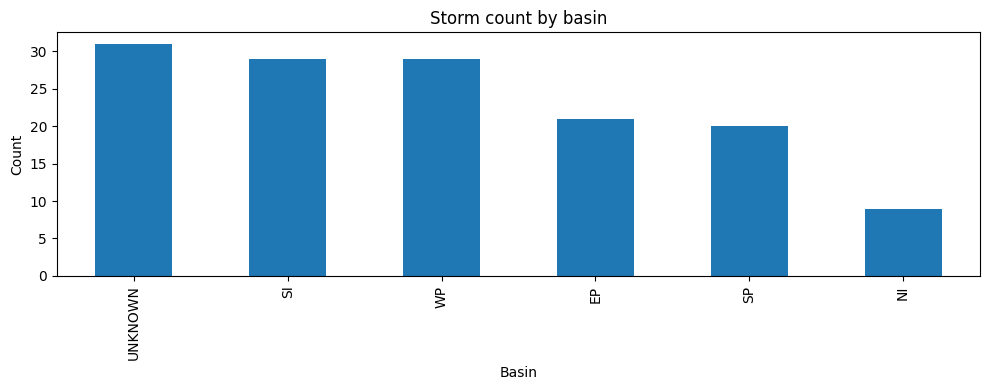

In [7]:
if "basin" in storms.columns:
    basin_counts = storms["basin"].fillna("UNKNOWN").value_counts().sort_values(ascending=False)
    display(basin_counts.to_frame("count"))

    plt.figure(figsize=(10, 4))
    basin_counts.plot(kind="bar")
    plt.title("Storm count by basin")
    plt.ylabel("Count")
    plt.xlabel("Basin")
    plt.tight_layout()
    plt.show()

,count
season,
2020,110
2021,29


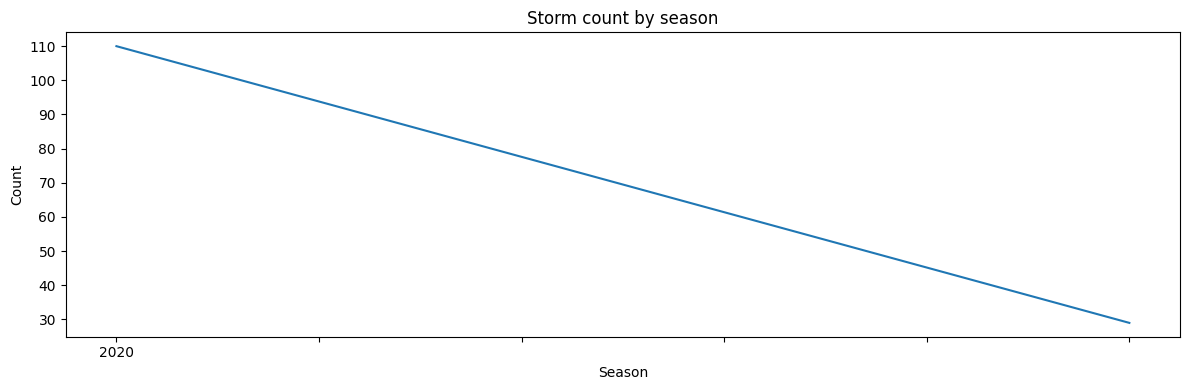

In [8]:
if "season" in storms.columns:
    season_counts = storms["season"].value_counts().sort_index()
    display(season_counts.tail(20).to_frame("count"))

    plt.figure(figsize=(12, 4))
    season_counts.plot()
    plt.title("Storm count by season")
    plt.ylabel("Count")
    plt.xlabel("Season")
    plt.tight_layout()
    plt.show()

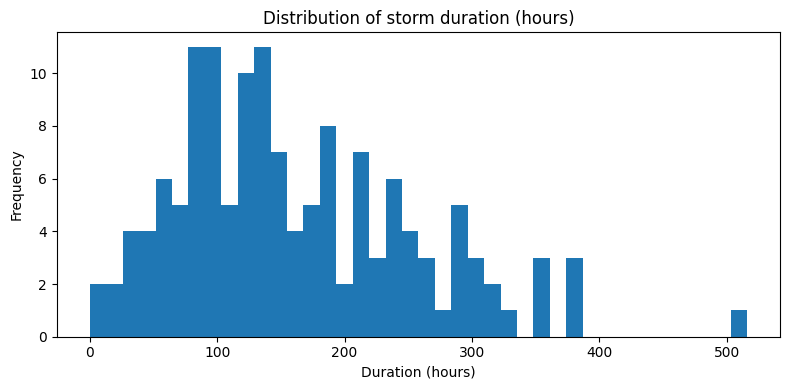

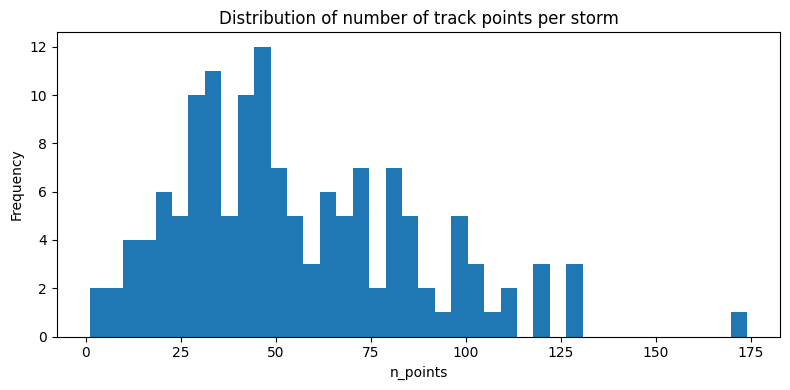

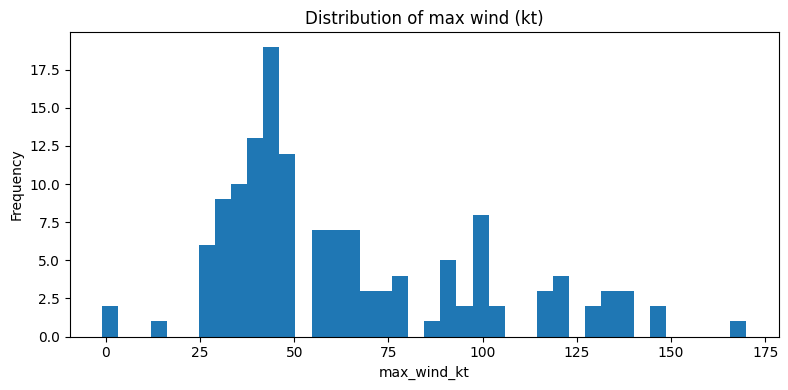

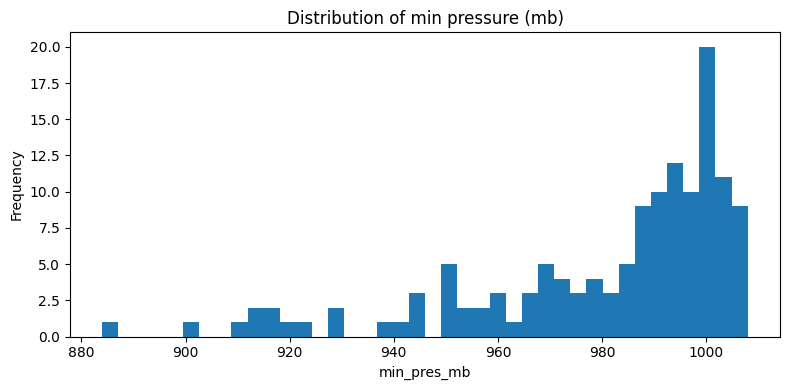

In [9]:
plt.figure(figsize=(8, 4))
storms["duration_hours"].dropna().plot(kind="hist", bins=40)
plt.title("Distribution of storm duration (hours)")
plt.xlabel("Duration (hours)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
storms["n_points"].dropna().plot(kind="hist", bins=40)
plt.title("Distribution of number of track points per storm")
plt.xlabel("n_points")
plt.tight_layout()
plt.show()

if "max_wind_kt" in storms.columns:
    plt.figure(figsize=(8, 4))
    storms["max_wind_kt"].dropna().plot(kind="hist", bins=40)
    plt.title("Distribution of max wind (kt)")
    plt.xlabel("max_wind_kt")
    plt.tight_layout()
    plt.show()

if "min_pres_mb" in storms.columns:
    plt.figure(figsize=(8, 4))
    storms["min_pres_mb"].dropna().plot(kind="hist", bins=40)
    plt.title("Distribution of min pressure (mb)")
    plt.xlabel("min_pres_mb")
    plt.tight_layout()
    plt.show()

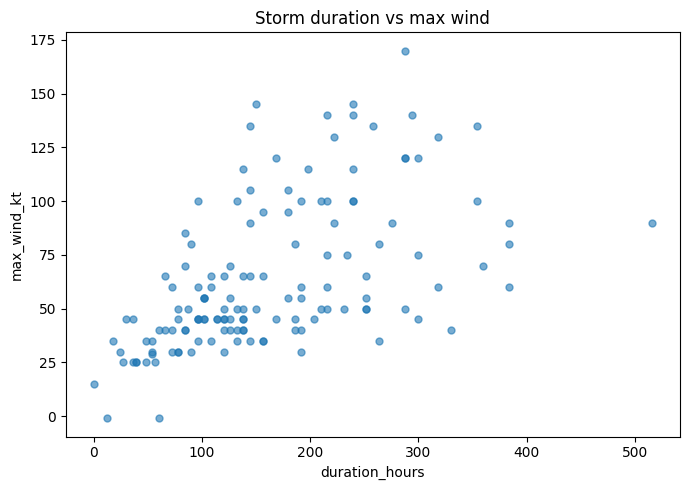

In [10]:
if {"duration_hours", "max_wind_kt"}.issubset(storms.columns):
    plt.figure(figsize=(7, 5))
    plt.scatter(
        storms["duration_hours"],
        storms["max_wind_kt"],
        alpha=0.6,
        s=25,
    )
    plt.xlabel("duration_hours")
    plt.ylabel("max_wind_kt")
    plt.title("Storm duration vs max wind")
    plt.tight_layout()
    plt.show()

## Define event-selection criteria

This requires precursor windows (6, 12, 24, and 48 hours) before storm escalation, so storm selection should prioritize storms with enough temporal extent and enough metadata to support this.

1. **Viability**
   - enough duration
   - enough track points
   - usable intensity metadata

2. **Relevance**
   - storms strong enough to be interesting
   - preferably with clear intensification signatures

3. **Diversity**
   - don't choose all events from one basin or one narrow regime

4. **Usability**
   - easy to extract around
   - enough temporal data before a likely peak storm time

In [11]:
# starting thresholds, can be changed after looking at storm results
MIN_DURATION_HOURS = 48
MIN_POINTS = 10
MIN_MAX_WIND_KT = 50
MAX_MIN_PRESSURE_MB = 1000

print("starting thresholds:")
print("MIN_DURATION_HOURS =", MIN_DURATION_HOURS)
print("MIN_POINTS =", MIN_POINTS)
print("MIN_MAX_WIND_KT =", MIN_MAX_WIND_KT)
print("MAX_MIN_PRESSURE_MB =", MAX_MIN_PRESSURE_MB)

starting thresholds:
MIN_DURATION_HOURS = 48
MIN_POINTS = 10
MIN_MAX_WIND_KT = 50
MAX_MIN_PRESSURE_MB = 1000


In [12]:
storms = storms.copy()

storms["eligible_duration"] = storms["duration_hours"] >= MIN_DURATION_HOURS
storms["eligible_points"] = storms["n_points"] >= MIN_POINTS

if "max_wind_kt" in storms.columns:
    storms["eligible_wind"] = storms["max_wind_kt"].notna() & (storms["max_wind_kt"] >= MIN_MAX_WIND_KT)
else:
    storms["eligible_wind"] = False

if "min_pres_mb" in storms.columns:
    storms["eligible_pressure"] = storms["min_pres_mb"].notna() & (storms["min_pres_mb"] <= MAX_MIN_PRESSURE_MB)
else:
    storms["eligible_pressure"] = False

# start permissive, can narrow this later
# need duration, points, and at least one intensity indicator
storms["eligible_core"] = (
    storms["eligible_duration"]
    & storms["eligible_points"]
    & (storms["eligible_wind"] | storms["eligible_pressure"])
)

eligibility_counts = pd.Series({
    "total_storms": len(storms),
    "eligible_duration": storms["eligible_duration"].sum(),
    "eligible_points": storms["eligible_points"].sum(),
    "eligible_wind": storms["eligible_wind"].sum(),
    "eligible_pressure": storms["eligible_pressure"].sum(),
    "eligible_core": storms["eligible_core"].sum(),
})

eligibility_counts

total_storms         139
eligible_duration    129
eligible_points      135
eligible_wind         79
eligible_pressure    111
eligible_core        109
dtype: int64

In [13]:
# how many storms passed the screening?
candidates = storms.loc[storms["eligible_core"]].copy()
print("Candidates shape:", candidates.shape)

candidate_cols = [
    c for c in [
        "SID", "name", "season", "basin",
        "start_time", "end_time",
        "duration_hours", "n_points",
        "max_wind_kt", "min_pres_mb",
        "eligible_duration", "eligible_points",
        "eligible_wind", "eligible_pressure",
    ] if c in candidates.columns
]

candidates[candidate_cols].head(20)

Candidates shape: (109, 23)


,SID,name,season,basin,start_time,end_time,duration_hours,n_points,max_wind_kt,min_pres_mb,eligible_duration,eligible_points,eligible_wind,eligible_pressure
1,2020019S11063,UNNAMED,2020,SI,2020-01-20 00:00:00+00:00,2020-01-24 06:00:00+00:00,102.0,35,45.0,998.0,True,True,False,True
2,2020022S17043,DIANE,2020,SI,2020-01-22 06:00:00+00:00,2020-01-29 18:00:00+00:00,180.0,61,55.0,985.0,True,True,True,True
3,2020023S19056,ESAMI,2020,SI,2020-01-22 12:00:00+00:00,2020-01-26 12:00:00+00:00,96.0,33,45.0,991.0,True,True,False,True
4,2020024S14190,UNNAMED,2020,SP,2020-01-24 06:00:00+00:00,2020-01-28 18:00:00+00:00,108.0,37,35.0,1000.0,True,True,False,True
5,2020034S17129,DAMIEN,2020,SI,2020-02-03 00:00:00+00:00,2020-02-10 12:00:00+00:00,180.0,67,95.0,956.0,True,True,True,True
6,2020034S13063,FRANCISCO,2020,SI,2020-02-03 06:00:00+00:00,2020-02-15 18:00:00+00:00,300.0,101,45.0,993.0,True,True,False,True
7,2020037S13163,UESI,2020,SP,2020-02-06 06:00:00+00:00,2020-02-17 06:00:00+00:00,264.0,89,80.0,968.0,True,True,True,True
8,2020045S15075,GABEKILE,2020,SI,2020-02-13 18:00:00+00:00,2020-02-23 00:00:00+00:00,222.0,75,90.0,969.0,True,True,True,True
9,2020051S13186,VICKY,2020,SP,2020-02-20 00:00:00+00:00,2020-02-24 06:00:00+00:00,102.0,35,45.0,997.0,True,True,False,True
10,2020052S11181,WASI,2020,SP,2020-02-20 12:00:00+00:00,2020-02-23 12:00:00+00:00,72.0,25,60.0,993.0,True,True,True,True


## Rank candidate storms

This needs storm ranking before final strom selection.
- stronger winds
- lower pressure
- longer duration
- more track points

In [14]:
def minmax_scale(series: pd.Series) -> pd.Series:
    x = series.astype(float)
    xmin = x.min()
    xmax = x.max()
    if pd.isna(xmin) or pd.isna(xmax) or xmax == xmin:
        return pd.Series(np.zeros(len(x)), index=x.index, dtype=float)
    return (x - xmin) / (xmax - xmin)

candidates = candidates.copy()

candidates["score_duration"] = minmax_scale(candidates["duration_hours"])
candidates["score_points"] = minmax_scale(candidates["n_points"])

if "max_wind_kt" in candidates.columns:
    candidates["score_wind"] = minmax_scale(candidates["max_wind_kt"].fillna(candidates["max_wind_kt"].min()))
else:
    candidates["score_wind"] = 0.0

if "min_pres_mb" in candidates.columns:
    # ower pressure should rank higher, so must invert 
    pres_scaled = minmax_scale(candidates["min_pres_mb"].fillna(candidates["min_pres_mb"].max()))
    candidates["score_pressure"] = 1.0 - pres_scaled
else:
    candidates["score_pressure"] = 0.0

# these can be changed later
W_WIND = 0.35
W_PRESSURE = 0.25
W_DURATION = 0.25
W_POINTS = 0.15

candidates["selection_score"] = (
    W_WIND * candidates["score_wind"]
    + W_PRESSURE * candidates["score_pressure"]
    + W_DURATION * candidates["score_duration"]
    + W_POINTS * candidates["score_points"]
)

candidates = candidates.sort_values(
    ["selection_score", "max_wind_kt", "duration_hours"],
    ascending=[False, False, False]
).reset_index(drop=True)

rank_cols = [
    c for c in [
        "SID", "name", "season", "basin",
        "duration_hours", "n_points", "max_wind_kt", "min_pres_mb",
        "score_wind", "score_pressure", "score_duration", "score_points",
        "selection_score"
    ] if c in candidates.columns
]

candidates[rank_cols].head(25)

,SID,name,season,basin,duration_hours,n_points,max_wind_kt,min_pres_mb,score_wind,score_pressure,score_duration,score_points,selection_score
0,2020299N11144,GONI,2020,WP,288.0,97,170.0,884.0,1.000000,1.000000,0.506494,0.503226,0.802107
1,2021062S14064,HABANA,2021,SI,354.0,119,135.0,928.0,0.758621,0.620690,0.649351,0.645161,0.679802
2,2021035S11080,FARAJI,2021,SI,294.0,99,140.0,920.0,0.793103,0.689655,0.519481,0.516129,0.657289
3,2020306N15288,ETA,2020,None,318.0,110,130.0,922.0,0.724138,0.672414,0.571429,0.587097,0.652473
4,2020092S09155,HAROLD,2020,SP,240.0,81,145.0,909.0,0.827586,0.784483,0.402597,0.400000,0.646425
5,2020251N17319,PAULETTE,2020,None,516.0,174,90.0,965.0,0.448276,0.301724,1.000000,1.000000,0.632328
6,2020244N25146,HAISHEN,2020,WP,258.0,87,135.0,913.0,0.758621,0.750000,0.441558,0.438710,0.629213
7,2020346S13168,YASA,2021,SP,240.0,82,140.0,914.0,0.793103,0.741379,0.402597,0.406452,0.624548
8,2021058S14149,NIRAN,2021,SP,216.0,73,140.0,917.0,0.793103,0.715517,0.350649,0.348387,0.596386
9,2020136N10088,AMPHAN,2020,NI,150.0,51,145.0,901.0,0.827586,0.853448,0.207792,0.206452,0.585933


In [15]:
top_by_score = candidates.nlargest(15, "selection_score")
top_by_wind = candidates.nlargest(15, "max_wind_kt") if "max_wind_kt" in candidates.columns else pd.DataFrame()
top_by_duration = candidates.nlargest(15, "duration_hours")

display(top_by_score[rank_cols])
if len(top_by_wind) > 0:
    display(top_by_wind[rank_cols])
display(top_by_duration[rank_cols])

,SID,name,season,basin,duration_hours,n_points,max_wind_kt,min_pres_mb,score_wind,score_pressure,score_duration,score_points,selection_score
0,2020299N11144,GONI,2020,WP,288.0,97,170.0,884.0,1.000000,1.000000,0.506494,0.503226,0.802107
1,2021062S14064,HABANA,2021,SI,354.0,119,135.0,928.0,0.758621,0.620690,0.649351,0.645161,0.679802
2,2021035S11080,FARAJI,2021,SI,294.0,99,140.0,920.0,0.793103,0.689655,0.519481,0.516129,0.657289
3,2020306N15288,ETA,2020,None,318.0,110,130.0,922.0,0.724138,0.672414,0.571429,0.587097,0.652473
4,2020092S09155,HAROLD,2020,SP,240.0,81,145.0,909.0,0.827586,0.784483,0.402597,0.400000,0.646425
5,2020251N17319,PAULETTE,2020,None,516.0,174,90.0,965.0,0.448276,0.301724,1.000000,1.000000,0.632328
6,2020244N25146,HAISHEN,2020,WP,258.0,87,135.0,913.0,0.758621,0.750000,0.441558,0.438710,0.629213
7,2020346S13168,YASA,2021,SP,240.0,82,140.0,914.0,0.793103,0.741379,0.402597,0.406452,0.624548
8,2021058S14149,NIRAN,2021,SP,216.0,73,140.0,917.0,0.793103,0.715517,0.350649,0.348387,0.596386
9,2020136N10088,AMPHAN,2020,NI,150.0,51,145.0,901.0,0.827586,0.853448,0.207792,0.206452,0.585933


,SID,name,season,basin,duration_hours,n_points,max_wind_kt,min_pres_mb,score_wind,score_pressure,score_duration,score_points,selection_score
0,2020299N11144,GONI,2020,WP,288.0,97,170.0,884.0,1.000000,1.000000,0.506494,0.503226,0.802107
4,2020092S09155,HAROLD,2020,SP,240.0,81,145.0,909.0,0.827586,0.784483,0.402597,0.400000,0.646425
9,2020136N10088,AMPHAN,2020,NI,150.0,51,145.0,901.0,0.827586,0.853448,0.207792,0.206452,0.585933
2,2021035S11080,FARAJI,2021,SI,294.0,99,140.0,920.0,0.793103,0.689655,0.519481,0.516129,0.657289
7,2020346S13168,YASA,2021,SP,240.0,82,140.0,914.0,0.793103,0.741379,0.402597,0.406452,0.624548
8,2021058S14149,NIRAN,2021,SP,216.0,73,140.0,917.0,0.793103,0.715517,0.350649,0.348387,0.596386
1,2021062S14064,HABANA,2021,SI,354.0,119,135.0,928.0,0.758621,0.620690,0.649351,0.645161,0.679802
6,2020244N25146,HAISHEN,2020,WP,258.0,87,135.0,913.0,0.758621,0.750000,0.441558,0.438710,0.629213
15,2020318N16289,IOTA,2020,None,144.0,50,135.0,917.0,0.758621,0.715517,0.194805,0.200000,0.523098
3,2020306N15288,ETA,2020,None,318.0,110,130.0,922.0,0.724138,0.672414,0.571429,0.587097,0.652473


,SID,name,season,basin,duration_hours,n_points,max_wind_kt,min_pres_mb,score_wind,score_pressure,score_duration,score_points,selection_score
5,2020251N17319,PAULETTE,2020,None,516.0,174,90.0,965.0,0.448276,0.301724,1.000000,1.000000,0.632328
16,2021012S12086,ELOISE,2021,SI,384.0,129,90.0,968.0,0.448276,0.275862,0.714286,0.709677,0.510885
17,2020277N21141,CHAN-HOM,2020,WP,384.0,129,80.0,963.0,0.379310,0.318966,0.714286,0.709677,0.497523
30,2020332S11091,BONGOYO,2021,SI,384.0,129,60.0,989.0,0.241379,0.094828,0.714286,0.709677,0.393213
26,2020355S11065,CHALANE,2021,SI,360.0,121,70.0,985.0,0.310345,0.129310,0.662338,0.658065,0.405242
1,2021062S14064,HABANA,2021,SI,354.0,119,135.0,928.0,0.758621,0.620690,0.649351,0.645161,0.679802
13,2021053S13128,MARIAN,2021,SI,354.0,119,100.0,952.0,0.517241,0.413793,0.649351,0.645161,0.543595
44,2021020S13107,UNNAMED,2021,SI,330.0,111,40.0,995.0,0.103448,0.043103,0.597403,0.593548,0.285366
3,2020306N15288,ETA,2020,None,318.0,110,130.0,922.0,0.724138,0.672414,0.571429,0.587097,0.652473
36,2020366S12073,DANILO,2021,SI,318.0,107,60.0,984.0,0.241379,0.137931,0.571429,0.567742,0.346984


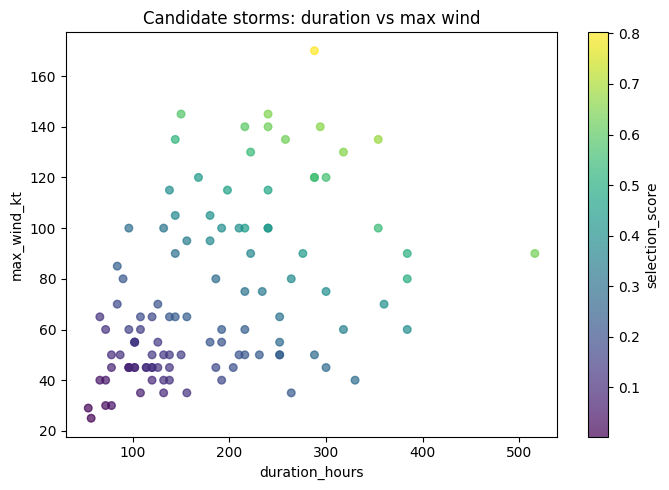

In [16]:
if {"duration_hours", "max_wind_kt", "selection_score"}.issubset(candidates.columns):
    plt.figure(figsize=(7, 5))
    sc = plt.scatter(
        candidates["duration_hours"],
        candidates["max_wind_kt"],
        c=candidates["selection_score"],
        s=30,
        alpha=0.7,
    )
    plt.xlabel("duration_hours")
    plt.ylabel("max_wind_kt")
    plt.title("Candidate storms: duration vs max wind")
    plt.colorbar(sc, label="selection_score")
    plt.tight_layout()
    plt.show()

## Diversity among top candidates

The final set should ideally include storms that are:
- strong
- long enough for lead up analysis
- not all from the same basin

So, this requires inspecting top-ranked storms

In [17]:
TOP_N_FOR_REVIEW = 30
review_pool = candidates.head(TOP_N_FOR_REVIEW).copy()

review_cols = [
    c for c in [
        "SID", "name", "season", "basin",
        "start_time", "end_time",
        "duration_hours", "n_points", "max_wind_kt", "min_pres_mb",
        "selection_score",
        "min_lat", "max_lat", "min_lon_180", "max_lon_180",
    ] if c in review_pool.columns
]

review_pool[review_cols]

,SID,name,season,basin,start_time,end_time,duration_hours,n_points,max_wind_kt,min_pres_mb,selection_score,min_lat,max_lat,min_lon_180,max_lon_180
0,2020299N11144,GONI,2020,WP,2020-10-25 06:00:00+00:00,2020-11-06 06:00:00+00:00,288.0,97,170.0,884.0,0.802107,10.6,16.7,107.9,143.9
1,2021062S14064,HABANA,2021,SI,2021-03-02 18:00:00+00:00,2021-03-17 12:00:00+00:00,354.0,119,135.0,928.0,0.679802,-23.7,-14.0,64.2,81.1
2,2021035S11080,FARAJI,2021,SI,2021-02-04 00:00:00+00:00,2021-02-16 06:00:00+00:00,294.0,99,140.0,920.0,0.657289,-20.3,-10.6,66.2,85.3
3,2020306N15288,ETA,2020,None,2020-10-31 18:00:00+00:00,2020-11-14 00:00:00+00:00,318.0,110,130.0,922.0,0.652473,13.6,35.7,-87.8,-69.2
4,2020092S09155,HAROLD,2020,SP,2020-04-01 00:00:00+00:00,2020-04-11 00:00:00+00:00,240.0,81,145.0,909.0,0.646425,-35.0,-9.2,-179.1,179.9
5,2020251N17319,PAULETTE,2020,None,2020-09-07 00:00:00+00:00,2020-09-28 12:00:00+00:00,516.0,174,90.0,965.0,0.632328,16.9,47.1,-64.9,-16.6
6,2020244N25146,HAISHEN,2020,WP,2020-08-30 12:00:00+00:00,2020-09-10 06:00:00+00:00,258.0,87,135.0,913.0,0.629213,19.3,45.9,124.0,146.4
7,2020346S13168,YASA,2021,SP,2020-12-11 06:00:00+00:00,2020-12-21 06:00:00+00:00,240.0,82,140.0,914.0,0.624548,-25.2,-12.8,-180.0,179.3
8,2021058S14149,NIRAN,2021,SP,2021-02-26 18:00:00+00:00,2021-03-07 18:00:00+00:00,216.0,73,140.0,917.0,0.596386,-28.8,-14.4,-178.1,179.8
9,2020136N10088,AMPHAN,2020,NI,2020-05-15 06:00:00+00:00,2020-05-21 12:00:00+00:00,150.0,51,145.0,901.0,0.585933,9.5,25.4,86.1,90.1


In [18]:
review_pool["basin"].fillna("UNKNOWN").value_counts()

basin
WP         9
SI         7
UNKNOWN    7
SP         3
EP         3
NI         1
Name: count, dtype: int64

In [19]:
review_pool["season"].value_counts().sort_index()

season
2020    22
2021     8
Name: count, dtype: int64

## Load point level IBTrACS data to determine time windows

This should include a peak storm time for each storm so downstream extraction can be consistent

Preferred choices:
1. time of maximum wind
2. time of minimum pressure
3. possibly midpoint of storm lifetime

In [20]:
points = None

if POINTS_PATH.exists():
    points = pd.read_parquet(POINTS_PATH).copy()
    if "ISO_TIME" in points.columns:
        points["ISO_TIME"] = pd.to_datetime(points["ISO_TIME"], utc=True, errors="coerce")
    print("Loaded point-level table:", points.shape)
    display(points.head())
else:
    print("Point-level parquet not found; anchor times will fall back to storm midpoint.")

Loaded point-level table: (7681, 178)


,SID,SEASON,BASIN,NAME,ISO_TIME,LAT,LON,lon_180,lon_360,wind_kt,pres_mb,NATURE,TRACK_TYPE,NUMBER,SUBBASIN,WMO_WIND,WMO_PRES,WMO_AGENCY,DIST2LAND,LANDFALL,IFLAG,USA_AGENCY,USA_ATCF_ID,USA_LAT,USA_LON,USA_RECORD,USA_STATUS,USA_WIND,USA_PRES,USA_SSHS,USA_R34_NE,USA_R34_SE,USA_R34_SW,USA_R34_NW,USA_R50_NE,USA_R50_SE,USA_R50_SW,USA_R50_NW,USA_R64_NE,USA_R64_SE,USA_R64_SW,USA_R64_NW,USA_POCI,USA_ROCI,USA_RMW,USA_EYE,TOKYO_LAT,TOKYO_LON,TOKYO_GRADE,TOKYO_WIND,...,BOM_POCI,BOM_EYE,BOM_POS_METHOD,BOM_PRES_METHOD,NADI_LAT,NADI_LON,NADI_CAT,NADI_WIND,NADI_PRES,WELLINGTON_LAT,WELLINGTON_LON,WELLINGTON_WIND,WELLINGTON_PRES,DS824_LAT,DS824_LON,DS824_STAGE,DS824_WIND,DS824_PRES,TD9636_LAT,TD9636_LON,TD9636_STAGE,TD9636_WIND,TD9636_PRES,TD9635_LAT,TD9635_LON,TD9635_WIND,TD9635_PRES,TD9635_ROCI,NEUMANN_LAT,NEUMANN_LON,NEUMANN_CLASS,NEUMANN_WIND,NEUMANN_PRES,MLC_LAT,MLC_LON,MLC_CLASS,MLC_WIND,MLC_PRES,USA_GUST,BOM_GUST,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,2020015S12170,2020,SP,TINO,2020-01-20 00:00:00+00:00,-35.8,199.7,-160.3,199.7,-1.0,<NA>,NR,main,3,MM,NaN,NaN,wellington,1883,1883,_________O_____,None,None,None,None,None,None,NaN,NaN,-5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,...,None,None,None,None,None,None,None,NaN,NaN,-35.8,-160.3,-1.0,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,47,155
1,2020015S12170,2020,SP,TINO,2020-01-20 03:00:00+00:00,-37.7,201.1,-158.9,201.1,-1.0,<NA>,NR,main,3,MM,NaN,NaN,None,1969,1968,_________P_____,None,None,None,None,None,None,NaN,NaN,-5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,...,None,None,None,None,None,None,None,NaN,NaN,-37.7,-158.9,-1.0,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,40,150
2,2020015S12170,2020,SP,TINO,2020-01-20 06:00:00+00:00,-39.2,202.3,-157.7,202.3,-1.0,<NA>,NR,main,3,MM,NaN,NaN,wellington,2058,2058,_________O_____,None,None,None,None,None,None,NaN,NaN,-5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,...,None,None,None,None,None,None,None,NaN,NaN,-39.2,-157.7,-1.0,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,28,145
3,2020015S12170,2020,SP,TINO,2020-01-20 09:00:00+00:00,-40.1,203.1,-156.9,203.1,-1.0,<NA>,NR,main,3,MM,NaN,NaN,None,2123,2123,_________P_____,None,None,None,None,None,None,NaN,NaN,-5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,...,None,None,None,None,None,None,None,NaN,NaN,-40.1,-156.9,-1.0,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,17,145
4,2020015S12170,2020,SP,TINO,2020-01-20 12:00:00+00:00,-40.6,203.5,-156.5,203.5,-1.0,<NA>,NR,main,3,MM,NaN,NaN,wellington,2157,None,_________O_____,None,None,None,None,None,None,NaN,NaN,-5,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,...,None,None,None,None,None,None,None,NaN,NaN,-40.6,-156.5,-1.0,NaN,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,None,NaN,NaN,None,None,None,None,None,None,None,None,None,None,13,150


In [21]:
def compute_peak_times_from_points(points_df: pd.DataFrame) -> pd.DataFrame:
    records = []

    for sid, grp in points_df.groupby("SID", sort=False):
        grp = grp.sort_values("ISO_TIME").copy()

        anchor_time = pd.NaT
        anchor_type = pd.NA

        if "wind_kt" in grp.columns and grp["wind_kt"].notna().any():
            idx = grp["wind_kt"].idxmax()
            anchor_time = grp.loc[idx, "ISO_TIME"]
            anchor_type = "max_wind"
        elif "pres_mb" in grp.columns and grp["pres_mb"].notna().any():
            idx = grp["pres_mb"].idxmin()
            anchor_time = grp.loc[idx, "ISO_TIME"]
            anchor_type = "min_pressure"

        records.append({
            "SID": sid,
            "anchor_time": anchor_time,
            "anchor_type": anchor_type,
        })

    return pd.DataFrame(records)

if points is not None:
    anchor_df = compute_peak_times_from_points(points)
    display(anchor_df.head())
else:
    anchor_df = pd.DataFrame(columns=["SID", "anchor_time", "anchor_type"])

,SID,anchor_time,anchor_type
0,2020015S12170,2020-01-20 00:00:00+00:00,max_wind
1,2020019S11063,2020-01-22 21:00:00+00:00,max_wind
2,2020022S17043,2020-01-25 18:00:00+00:00,max_wind
3,2020023S19056,2020-01-25 00:00:00+00:00,max_wind
4,2020024S14190,2020-01-25 12:00:00+00:00,max_wind


In [22]:
storms_with_peak = storms.merge(anchor_df, on="SID", how="left")
midpoint = storms_with_peak["start_time"] + (
    storms_with_peak["end_time"] - storms_with_peak["start_time"]
) / 2

storms_with_peak["anchor_time"] = storms_with_peak["anchor_time"].fillna(midpoint)
storms_with_peak["anchor_type"] = storms_with_peak["anchor_type"].fillna("midpoint_fallback")

storms_with_peak[[
    c for c in ["SID", "name", "start_time", "end_time", "anchor_time", "anchor_type"] if c in storms_with_peak.columns
]].head(20)

,SID,name,start_time,end_time,anchor_time,anchor_type
0,2020015S12170,TINO,2020-01-20 00:00:00+00:00,2020-01-20 12:00:00+00:00,2020-01-20 00:00:00+00:00,max_wind
1,2020019S11063,UNNAMED,2020-01-20 00:00:00+00:00,2020-01-24 06:00:00+00:00,2020-01-22 21:00:00+00:00,max_wind
2,2020022S17043,DIANE,2020-01-22 06:00:00+00:00,2020-01-29 18:00:00+00:00,2020-01-25 18:00:00+00:00,max_wind
3,2020023S19056,ESAMI,2020-01-22 12:00:00+00:00,2020-01-26 12:00:00+00:00,2020-01-25 00:00:00+00:00,max_wind
4,2020024S14190,UNNAMED,2020-01-24 06:00:00+00:00,2020-01-28 18:00:00+00:00,2020-01-25 12:00:00+00:00,max_wind
5,2020034S17129,DAMIEN,2020-02-03 00:00:00+00:00,2020-02-10 12:00:00+00:00,2020-02-08 06:00:00+00:00,max_wind
6,2020034S13063,FRANCISCO,2020-02-03 06:00:00+00:00,2020-02-15 18:00:00+00:00,2020-02-05 06:00:00+00:00,max_wind
7,2020037S13163,UESI,2020-02-06 06:00:00+00:00,2020-02-17 06:00:00+00:00,2020-02-11 18:00:00+00:00,max_wind
8,2020045S15075,GABEKILE,2020-02-13 18:00:00+00:00,2020-02-23 00:00:00+00:00,2020-02-16 00:00:00+00:00,max_wind
9,2020051S13186,VICKY,2020-02-20 00:00:00+00:00,2020-02-24 06:00:00+00:00,2020-02-21 00:00:00+00:00,max_wind


## Final manual storm curation

Storm selection becomes a judgment call

- start with the top-ranked candidates
- choose 6–10 storms
- pick strong storm that are long enough and have good metadata
- try to include some basin or seasonal diversity

In [24]:
# Inspect these tables first, then manually fill in FINAL_SELECTED_SIDS.
display(candidates.head(30)[review_cols])

# to replicate, replace these with your chosen SIDs, these are just the ones I picked
FINAL_SELECTED_SIDS = [
    "2020299N11144", # GONI: typical extreme storm
    "2021035S11080", # FARAJI: similar to GONI but different hemisphere
    "2021062S14064", # HABANA: longest storm for analyzing storm buildup
    "2020092S09155", # HAROLD: strong but short
    "2020306N15288", # ETA: ramps up, calms, and ramps up again
    "2020244N25146", # HAISHEN: same hemisphere, different structure than GONI
    "2020251N17319", # PAULETTE: long but comparatively weaker, good for intensity comparisons
    "2020034S17129", # DAMIEN: middle duration and strength
]

print("Number of selected SIDs:", len(FINAL_SELECTED_SIDS))
FINAL_SELECTED_SIDS

,SID,name,season,basin,start_time,end_time,duration_hours,n_points,max_wind_kt,min_pres_mb,selection_score,min_lat,max_lat,min_lon_180,max_lon_180
0,2020299N11144,GONI,2020,WP,2020-10-25 06:00:00+00:00,2020-11-06 06:00:00+00:00,288.0,97,170.0,884.0,0.802107,10.6,16.7,107.9,143.9
1,2021062S14064,HABANA,2021,SI,2021-03-02 18:00:00+00:00,2021-03-17 12:00:00+00:00,354.0,119,135.0,928.0,0.679802,-23.7,-14.0,64.2,81.1
2,2021035S11080,FARAJI,2021,SI,2021-02-04 00:00:00+00:00,2021-02-16 06:00:00+00:00,294.0,99,140.0,920.0,0.657289,-20.3,-10.6,66.2,85.3
3,2020306N15288,ETA,2020,None,2020-10-31 18:00:00+00:00,2020-11-14 00:00:00+00:00,318.0,110,130.0,922.0,0.652473,13.6,35.7,-87.8,-69.2
4,2020092S09155,HAROLD,2020,SP,2020-04-01 00:00:00+00:00,2020-04-11 00:00:00+00:00,240.0,81,145.0,909.0,0.646425,-35.0,-9.2,-179.1,179.9
5,2020251N17319,PAULETTE,2020,None,2020-09-07 00:00:00+00:00,2020-09-28 12:00:00+00:00,516.0,174,90.0,965.0,0.632328,16.9,47.1,-64.9,-16.6
6,2020244N25146,HAISHEN,2020,WP,2020-08-30 12:00:00+00:00,2020-09-10 06:00:00+00:00,258.0,87,135.0,913.0,0.629213,19.3,45.9,124.0,146.4
7,2020346S13168,YASA,2021,SP,2020-12-11 06:00:00+00:00,2020-12-21 06:00:00+00:00,240.0,82,140.0,914.0,0.624548,-25.2,-12.8,-180.0,179.3
8,2021058S14149,NIRAN,2021,SP,2021-02-26 18:00:00+00:00,2021-03-07 18:00:00+00:00,216.0,73,140.0,917.0,0.596386,-28.8,-14.4,-178.1,179.8
9,2020136N10088,AMPHAN,2020,NI,2020-05-15 06:00:00+00:00,2020-05-21 12:00:00+00:00,150.0,51,145.0,901.0,0.585933,9.5,25.4,86.1,90.1


Number of selected SIDs: 8


['2020299N11144',
 '2021035S11080',
 '2021062S14064',
 '2020092S09155',
 '2020306N15288',
 '2020244N25146',
 '2020251N17319',
 '2020034S17129']

In [26]:
if len(FINAL_SELECTED_SIDS) == 0:
    print("No final SIDs selected yet. Review the ranked table above, then pick FINAL_SELECTED_SIDS for the storms you want!")
else:
    selected = storms_with_peak.loc[storms_with_peak["SID"].isin(FINAL_SELECTED_SIDS)].copy()
    print("Selected shape:", selected.shape)
    display(selected[[
        c for c in [
            "SID", "name", "season", "basin",
            "start_time", "end_time", "anchor_time", "anchor_type",
            "duration_hours", "n_points", "max_wind_kt", "min_pres_mb"
        ] if c in selected.columns
    ]].sort_values("anchor_time"))

Selected shape: (8, 25)


,SID,name,season,basin,start_time,end_time,anchor_time,anchor_type,duration_hours,n_points,max_wind_kt,min_pres_mb
5,2020034S17129,DAMIEN,2020,SI,2020-02-03 00:00:00+00:00,2020-02-10 12:00:00+00:00,2020-02-08 06:00:00+00:00,max_wind,180.0,67,95.0,956.0
17,2020092S09155,HAROLD,2020,SP,2020-04-01 00:00:00+00:00,2020-04-11 00:00:00+00:00,2020-04-06 06:00:00+00:00,max_wind,240.0,81,145.0,909.0
63,2020244N25146,HAISHEN,2020,WP,2020-08-30 12:00:00+00:00,2020-09-10 06:00:00+00:00,2020-09-04 06:00:00+00:00,max_wind,258.0,87,135.0,913.0
68,2020251N17319,PAULETTE,2020,None,2020-09-07 00:00:00+00:00,2020-09-28 12:00:00+00:00,2020-09-14 18:00:00+00:00,max_wind,516.0,174,90.0,965.0
97,2020299N11144,GONI,2020,WP,2020-10-25 06:00:00+00:00,2020-11-06 06:00:00+00:00,2020-10-31 18:00:00+00:00,max_wind,288.0,97,170.0,884.0
99,2020306N15288,ETA,2020,None,2020-10-31 18:00:00+00:00,2020-11-14 00:00:00+00:00,2020-11-03 00:00:00+00:00,max_wind,318.0,110,130.0,922.0
130,2021035S11080,FARAJI,2021,SI,2021-02-04 00:00:00+00:00,2021-02-16 06:00:00+00:00,2021-02-08 18:00:00+00:00,max_wind,294.0,99,140.0,920.0
137,2021062S14064,HABANA,2021,SI,2021-03-02 18:00:00+00:00,2021-03-17 12:00:00+00:00,2021-03-10 12:00:00+00:00,max_wind,354.0,119,135.0,928.0


## Build final event catalog

The final event catalog should be useful for later data extraction.

Each row should have:
- storm identity
- timing metadata
- a consistent peak time
- basic intensity metadata
- spatial extent metadata
- extraction defaults

In [27]:
DEFAULT_BOX_SIZE_DEG = 15
DEFAULT_PRE_HOURS = 48
DEFAULT_POST_HOURS = 0
DEFAULT_PRECURSOR_OFFSETS = "6,12,24,48"

if len(FINAL_SELECTED_SIDS) > 0:
    event_catalog = selected.copy()

    event_catalog = event_catalog.sort_values("anchor_time").reset_index(drop=True)
    event_catalog["priority_order"] = np.arange(1, len(event_catalog) + 1)
    event_catalog["event_id"] = [
        f"event_{i:02d}_{sid}" for i, sid in enumerate(event_catalog["SID"], start=1)
    ]

    event_catalog["box_size_deg"] = DEFAULT_BOX_SIZE_DEG
    event_catalog["pre_hours"] = DEFAULT_PRE_HOURS
    event_catalog["post_hours"] = DEFAULT_POST_HOURS
    event_catalog["precursor_offsets_hours"] = DEFAULT_PRECURSOR_OFFSETS
    event_catalog["selection_reason"] = pd.NA
    event_catalog["notes"] = pd.NA

    event_catalog_cols = [
        c for c in [
            "event_id",
            "priority_order",
            "SID",
            "name",
            "season",
            "basin",
            "start_time",
            "end_time",
            "anchor_time",
            "anchor_type",
            "duration_hours",
            "n_points",
            "max_wind_kt",
            "min_pres_mb",
            "min_lat",
            "max_lat",
            "min_lon_180",
            "max_lon_180",
            "box_size_deg",
            "pre_hours",
            "post_hours",
            "precursor_offsets_hours",
            "selection_reason",
            "notes",
        ] if c in event_catalog.columns
    ]

    event_catalog = event_catalog[event_catalog_cols].copy()
    display(event_catalog)
else:
    event_catalog = pd.DataFrame()
    print("Event catalog not created yet because FINAL_SELECTED_SIDS is empty.")

,event_id,priority_order,SID,name,season,basin,start_time,end_time,anchor_time,anchor_type,duration_hours,n_points,max_wind_kt,min_pres_mb,min_lat,max_lat,min_lon_180,max_lon_180,box_size_deg,pre_hours,post_hours,precursor_offsets_hours,selection_reason,notes
0,event_01_2020034S17129,1,2020034S17129,DAMIEN,2020,SI,2020-02-03 00:00:00+00:00,2020-02-10 12:00:00+00:00,2020-02-08 06:00:00+00:00,max_wind,180.0,67,95.0,956.0,-25.7,-16.0,116.4,129.3,15,48,0,"6,12,24,48",<NA>,<NA>
1,event_02_2020092S09155,2,2020092S09155,HAROLD,2020,SP,2020-04-01 00:00:00+00:00,2020-04-11 00:00:00+00:00,2020-04-06 06:00:00+00:00,max_wind,240.0,81,145.0,909.0,-35.0,-9.2,-179.1,179.9,15,48,0,"6,12,24,48",<NA>,<NA>
2,event_03_2020244N25146,3,2020244N25146,HAISHEN,2020,WP,2020-08-30 12:00:00+00:00,2020-09-10 06:00:00+00:00,2020-09-04 06:00:00+00:00,max_wind,258.0,87,135.0,913.0,19.3,45.9,124.0,146.4,15,48,0,"6,12,24,48",<NA>,<NA>
3,event_04_2020251N17319,4,2020251N17319,PAULETTE,2020,None,2020-09-07 00:00:00+00:00,2020-09-28 12:00:00+00:00,2020-09-14 18:00:00+00:00,max_wind,516.0,174,90.0,965.0,16.9,47.1,-64.9,-16.6,15,48,0,"6,12,24,48",<NA>,<NA>
4,event_05_2020299N11144,5,2020299N11144,GONI,2020,WP,2020-10-25 06:00:00+00:00,2020-11-06 06:00:00+00:00,2020-10-31 18:00:00+00:00,max_wind,288.0,97,170.0,884.0,10.6,16.7,107.9,143.9,15,48,0,"6,12,24,48",<NA>,<NA>
5,event_06_2020306N15288,6,2020306N15288,ETA,2020,None,2020-10-31 18:00:00+00:00,2020-11-14 00:00:00+00:00,2020-11-03 00:00:00+00:00,max_wind,318.0,110,130.0,922.0,13.6,35.7,-87.8,-69.2,15,48,0,"6,12,24,48",<NA>,<NA>
6,event_07_2021035S11080,7,2021035S11080,FARAJI,2021,SI,2021-02-04 00:00:00+00:00,2021-02-16 06:00:00+00:00,2021-02-08 18:00:00+00:00,max_wind,294.0,99,140.0,920.0,-20.3,-10.6,66.2,85.3,15,48,0,"6,12,24,48",<NA>,<NA>
7,event_08_2021062S14064,8,2021062S14064,HABANA,2021,SI,2021-03-02 18:00:00+00:00,2021-03-17 12:00:00+00:00,2021-03-10 12:00:00+00:00,max_wind,354.0,119,135.0,928.0,-23.7,-14.0,64.2,81.1,15,48,0,"6,12,24,48",<NA>,<NA>


In [29]:
if len(event_catalog) > 0:
    checks = {
        "n_events": len(event_catalog),
        "unique_sid": event_catalog["SID"].nunique(),
        "unique_event_id": event_catalog["event_id"].nunique(),
        "anchor_notna": event_catalog["anchor_time"].notna().mean(),
        "start_notna": event_catalog["start_time"].notna().mean(),
        "end_notna": event_catalog["end_time"].notna().mean(),
        "anchor_within_lifetime": (
            (event_catalog["anchor_time"] >= event_catalog["start_time"]) &
            (event_catalog["anchor_time"] <= event_catalog["end_time"])
        ).mean(),
    }
    print(pd.Series(checks))

n_events                  8.0
unique_sid                8.0
unique_event_id           8.0
anchor_notna              1.0
start_notna               1.0
end_notna                 1.0
anchor_within_lifetime    1.0
dtype: float64


## Save outputs
**Ranked candidate table**: useful for review, revision, and reproducibility

**Final event catalog**: downstream input for window extraction

In [30]:
# save ranked candidates regardless of final storms
candidates.to_parquet(RANKED_CANDIDATES_PARQUET, index=False)
candidates.to_csv(RANKED_CANDIDATES_CSV, index=False)

print("Saved ranked candidates:")
print(" -", RANKED_CANDIDATES_PARQUET)
print(" -", RANKED_CANDIDATES_CSV)

if len(event_catalog) > 0:
    event_catalog.to_parquet(EVENT_CATALOG_PARQUET, index=False)
    event_catalog.to_csv(EVENT_CATALOG_CSV, index=False)

    print("\nSaved event catalog:")
    print(" -", EVENT_CATALOG_PARQUET)
    print(" -", EVENT_CATALOG_CSV)
else:
    print("\nEvent catalog not saved because no final SIDs have been selected yet.")

Saved ranked candidates:
 - /home/exouser/SciVis_2026/data/interim/storm_candidates_ranked.parquet
 - /home/exouser/SciVis_2026/data/interim/storm_candidates_ranked.csv


OSError: Cannot save file into a non-existent directory: '/home/exouser/SciVis_2026/data/processed'